In [37]:
import pandas as pd

df = pd.read_csv("C:/Users/Ruchi/Downloads/Customer_Churn_Unclean_Dataset.csv")
df.head()

,Customer_ID,Age,Gender,Tenure_Months,Monthly_Charges,Total_Charges,Contract_Type,Payment_Method,Internet_Service,Customer_Support_Calls,Churn
0,10001,56,Male,43,3132.19,33157.99,Monthly,Credit Card,Fiber,14,No
1,10002,69,Female,10,1698.04,24552.47,Quarterly,UPI,DSL,2,Yes
2,10003,46,Male,1,641.04,152375.27,Monthly,UPI,NaN,4,No
3,10004,32,Male,49,1037.52,185573.21,Yearly,UPI,Fiber,3,No
4,10005,60,Female,11,3300.36,92198.36,Quarterly,UPI,DSL,6,No


In [38]:
print("Shape:", df.shape)
print(df.info())
print(df.describe())

Shape: (3000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             3000 non-null   int64  
 1   Age                     3000 non-null   int64  
 2   Gender                  3000 non-null   object 
 3   Tenure_Months           3000 non-null   int64  
 4   Monthly_Charges         3000 non-null   float64
 5   Total_Charges           3000 non-null   float64
 6   Contract_Type           3000 non-null   object 
 7   Payment_Method          3000 non-null   object 
 8   Internet_Service        2014 non-null   object 
 9   Customer_Support_Calls  3000 non-null   int64  
 10  Churn                   3000 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 257.9+ KB
None
        Customer_ID          Age  Tenure_Months  Monthly_Charges  \
count   3000.000000  3000.000000    3000.000000  

In [39]:
df.isnull().sum()

Customer_ID                 0
Age                         0
Gender                      0
Tenure_Months               0
Monthly_Charges             0
Total_Charges               0
Contract_Type               0
Payment_Method              0
Internet_Service          986
Customer_Support_Calls      0
Churn                       0
dtype: int64

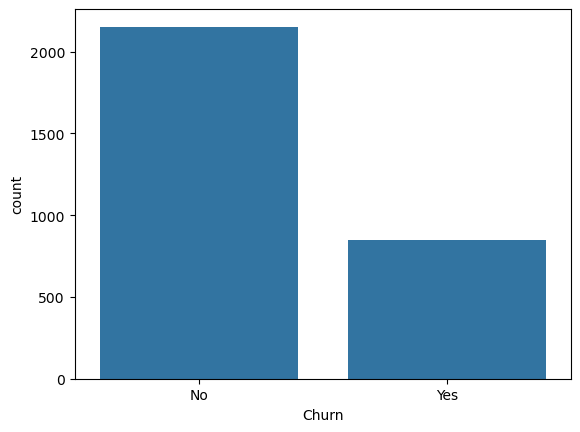

Churn
No     0.717333
Yes    0.282667
Name: proportion, dtype: float64

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.show()

df['Churn'].value_counts(normalize=True)

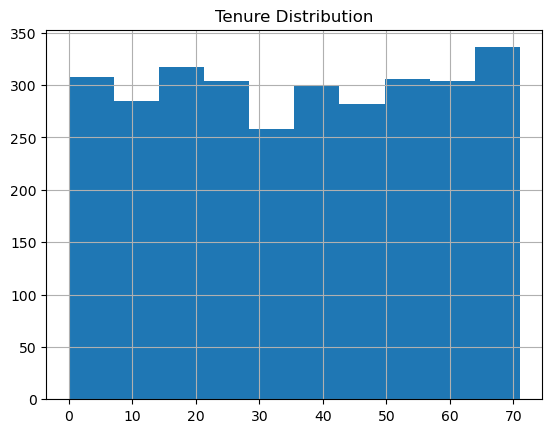

In [41]:
df['Tenure_Months'].hist()
plt.title("Tenure Distribution")
plt.show()

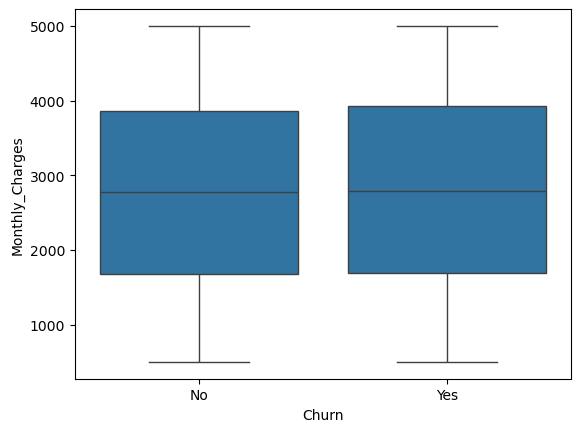

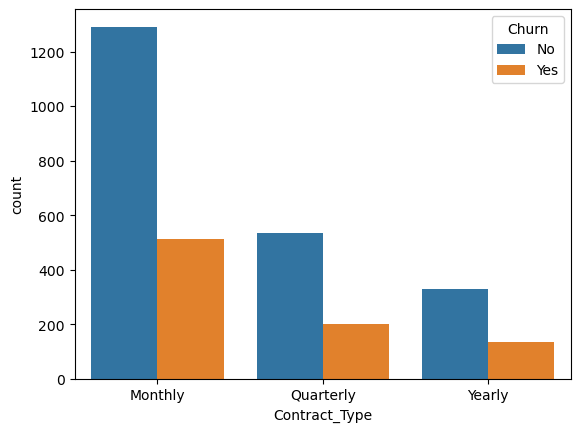

In [42]:
sns.boxplot(x='Churn', y='Monthly_Charges', data=df)
plt.show()

sns.countplot(x='Contract_Type', hue='Churn', data=df)
plt.show()

In [43]:
df.fillna(method='ffill', inplace=True)

C:\Users\Ruchi\AppData\Local\Temp\ipykernel_19888\3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [44]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [45]:
df = pd.get_dummies(df, drop_first=True)

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['Tenure_Months', 'Monthly_Charges', 'Total_Charges']

df[num_cols] = scaler.fit_transform(df[num_cols])

In [47]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [48]:
def tenure_group(x):
    if x <= 12:
        return "0-1 Year"
    elif x <= 24:
        return "1-2 Years"
    elif x <= 48:
        return "2-4 Years"
    else:
        return "4+ Years"

df['tenure_group'] = df['Tenure_Months'].apply(tenure_group)

In [49]:
df['Total_Charges'] = pd.qcut(df['Monthly_Charges'], 3, labels=['Low', 'Medium', 'High'])

In [50]:
df['Customer_Support_Calls'] = df['Customer_Support_Calls'] / (df['Tenure_Months'] + 1)

In [51]:
df.drop(['Customer_ID'], axis=1, inplace=True)

In [52]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

C:\Users\Ruchi\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [79]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [80]:
y_prob_lr = lr.predict_proba(X_test)[:,1]
y_prob_dt = dt.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_auc_score

print("ROC-AUC LR:", roc_auc_score(y_test, y_prob_lr))
print("ROC-AUC DT:", roc_auc_score(y_test, y_prob_dt))

ROC-AUC LR: 0.46190759358880396
ROC-AUC DT: 0.45775884720167054


In [81]:
print("Fixed ROC LR:", roc_auc_score(y_test, 1 - y_prob_lr))
print("Fixed ROC DT:", roc_auc_score(y_test, 1 - y_prob_dt))

Fixed ROC LR: 0.538092406411196
Fixed ROC DT: 0.5422411527983294


In [82]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [83]:
from sklearn.metrics import classification_report, roc_auc_score

print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))
print("Decision Tree:\n", classification_report(y_test, y_pred_dt))

print("ROC-AUC LR:", roc_auc_score(y_test, y_pred_lr))
print("ROC-AUC DT:", roc_auc_score(y_test, y_pred_dt))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.72      1.00      0.83       430
           1       0.00      0.00      0.00       170

    accuracy                           0.72       600
   macro avg       0.36      0.50      0.42       600
weighted avg       0.51      0.72      0.60       600

Decision Tree:
               precision    recall  f1-score   support

           0       0.71      0.98      0.83       430
           1       0.17      0.01      0.02       170

    accuracy                           0.70       600
   macro avg       0.44      0.49      0.42       600
weighted avg       0.56      0.70      0.60       600

ROC-AUC LR: 0.5
ROC-AUC DT: 0.49425444596443224


C:\Users\Ruchi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Ruchi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Ruchi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [84]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Align columns (important!)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [85]:
dt.fit(X_train, y_train)

print("Train Score DT:", dt.score(X_train, y_train))
print("Test Score DT:", dt.score(X_test, y_test))

Train Score DT: 0.7241666666666666
Test Score DT: 0.705


DecisionTreeClassifier()

In [86]:
print("Train Score LR:", lr.score(X_train, y_train))
print("Test Score LR:", lr.score(X_test, y_test))

print("Train Score DT:", dt.score(X_train, y_train))
print("Test Score DT:", dt.score(X_test, y_test))

Train Score LR: 0.7175
Test Score LR: 0.7166666666666667
Train Score DT: 0.7241666666666666
Test Score DT: 0.705


In [88]:
import pandas as pd

feature_importance = pd.Series(dt.feature_importances_, index=X_train.columns)
feature_importance.sort_values(ascending=False).head(10)

Monthly_Charges               0.450941
Customer_Support_Calls        0.219716
Age                           0.140110
Tenure_Months                 0.101960
Contract_Type_Quarterly       0.045005
Payment_Method_Net Banking    0.042268
Gender_Male                   0.000000
Contract_Type_Yearly          0.000000
Payment_Method_Debit Card     0.000000
Payment_Method_UPI            0.000000
dtype: float64

In [90]:
import pickle

with open("customer churn analysis.pkl", "wb") as f:
    pickle.dump(lr, f)

In [93]:
import pickle

with open("costumer churn analysis.pkl", "wb") as f:
    pickle.dump(dt, f)